(sec:ecd)=
# Optical activity and dichroism

VeloxChem enables simulations of molecular optical activity by providing access to rotatory strengths, specific rotations, and circular dichroism spectra through density‑functional theory response methods. These chiroptical properties can be obtained either from an eigenvalue‑based TDDFT treatment of excited states or through the complex polarization propagator (CPP) approach, which delivers frequency‑dependent spectra directly comparable to experiment. For further theoretical details, see {cite}`Norman2018`.

## Rotatory strengths

The strength of an ECD band is given by the anisotropy of the [decadic molar extinction coefficient](https://en.wikipedia.org/wiki/Molar_attenuation_coefficient)

$$
\Delta\epsilon(\omega) =
\frac{
	16\pi N_\mathrm{A}
}{
  	\ln\left(10\right)
	\left(4\pi\varepsilon_0\right) c^2
}
\frac{\pi}{3 \hbar}
\sum_{n>0} f(\omega; \omega_{n0},\gamma)\, 
\omega_{n0} R_{n0} 
$$

where $N_\mathrm{A}$ is [Avogadro's constant](https://en.wikipedia.org/wiki/Avogadro_constant), $f$ is the [Cauchy distribution](https://en.wikipedia.org/wiki/Cauchy_distribution), and $R_{n0}$ is the rotatory strength defined as

$$
R_{n0} =
\sum_{\alpha = x,y,z}
\Im 
\langle 0 | \hat{\mu}_\alpha | n \rangle
\langle n | \hat{m}_\alpha | 0\rangle 
=
\sum_{\alpha = x,y,z}
\frac{-e}{m_\mathrm{e} \omega_{n0}}
\langle 0 | \hat{p}_\alpha | n \rangle
\langle n | \hat{m}_\alpha | 0\rangle
$$

In VeloxChem, the rotatory strength is evaluated in the velocity gauge as given in the second expression, and it is thereby gauge-origin independent.

**Python script**

In [8]:
import veloxchem as vlx

molecule = vlx.Molecule.read_name("methyloxirane")
basis = vlx.MolecularBasis.read(molecule, "def2-svp")

scf_drv = vlx.ScfRestrictedDriver()
scf_drv.xcfun = "b3lyp"
scf_results = scf_drv.compute(molecule, basis)

rsp_drv = vlx.LinearResponseEigenSolver()
rsp_drv.nstates = 5
rsp_results = rsp_drv.compute(molecule, basis, scf_results)

Reading methyloxirane from PubChem...

Reference: S. Kim, J. Chen, T. Cheng, A. Gindulyte, J. He, S. He, Q. Li, B. A. Shoemaker, P. A. Thiessen, B. Yu, L. Zaslavsky, J. Zhang, E. E. Bolton, Nucleic Acids Res., 2025, 53, D1516-D1525.

Please double-check the compound since names may refer to more than one record.

                                                                                                                          
                                            Self Consistent Field Driver Setup                                            
                                                                                                                          
                   Wave Function Model             : Spin-Restricted Kohn-Sham                                            
                   Initial Guess Model             : Superposition of Atomic Densities                                    
                   Convergence Accelerator         : Two Level Direct 

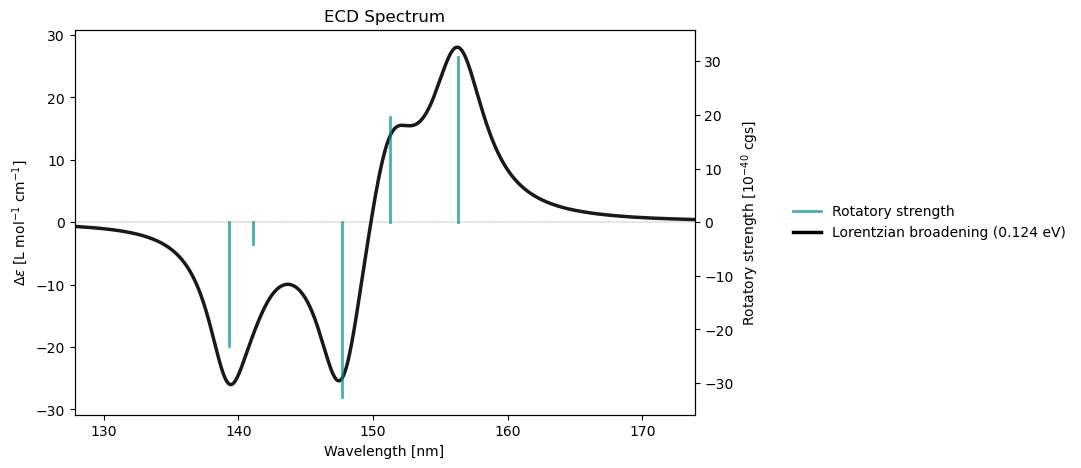

In [9]:
rsp_drv.plot_ecd(rsp_results)

**Text file**

:::{code}
@jobs
task: response
@end

@method settings
basis: def2-svpd
xcfun: b3lyp
@end

@response
property: ecd
nstates: 10
nto: yes
@end

@molecule
charge: 0
multiplicity: 1
xyz:
...
@end
:::

## Extinction coefficient

The anisotropy of the decadic molar extinction coefficient can be determined directly from the complex polarization propagator evaluated for mixed electric- and magnetic-dipole operators {cite}` Jiem2007`

$$
\Delta\epsilon(\omega) =
\frac{
	16 \pi N_\mathrm{A}
	\omega^2
}{
  	\ln(10)
	\left(4\pi\varepsilon_0\right) c^2
}
\,
\beta(\omega)
$$

where the molecular response property, $\beta(\omega)$, is defined as

$$
\beta(\omega) = -\frac{1}{3 \omega} (G_{xx} + G_{yy} + G_{zz})
$$

and

$$
G_{\alpha\beta} = - \Re\langle\langle\hat{\mu}_\alpha;\hat{m}_\beta
\rangle\rangle_\omega^\gamma = -
\frac{e}{\omega m_e}
\Im 
\langle\langle\hat{p}_\alpha;
\hat{m}_\beta
\rangle\rangle_\omega^\gamma
$$

The mixed electric–magnetic dipole tensor, $G$, is evaluated in the velocity gauge as given in the second expression. Furthermore, it is complex and calculated with a damping term, $\hbar \gamma$, associated with the inverse finite lifetime of the excited states. The default program setting for this parameter is 0.124 eV (or 0.004556 a.u.).

The resulting values for $\Delta \epsilon(\omega)$ 
are converted  from atomic units to units of L mol$^{-1}$ cm$^{-1}$ by multiplying with a factor of $10\, a_0^2$.

**Python script**

In [18]:
import numpy as np
import veloxchem as vlx

molecule = vlx.Molecule.read_name("methyloxirane")
basis = vlx.MolecularBasis.read(molecule, "def2-svp")

scf_drv = vlx.ScfRestrictedDriver()
scf_drv.xcfun = "b3lyp"
scf_results = scf_drv.compute(molecule, basis)

cpp_drv = vlx.ComplexResponse()
cpp_drv.frequencies = np.arange(0.25, 0.35, 0.0025)
cpp_drv.damping = 0.0045563
cpp_drv.cpp_flag = "ecd"

cpp_results = cpp_drv.compute(molecule, basis, scf_results)

Reading methyloxirane from PubChem...

Reference: S. Kim, J. Chen, T. Cheng, A. Gindulyte, J. He, S. He, Q. Li, B. A. Shoemaker, P. A. Thiessen, B. Yu, L. Zaslavsky, J. Zhang, E. E. Bolton, Nucleic Acids Res., 2025, 53, D1516-D1525.

Please double-check the compound since names may refer to more than one record.

                                                                                                                          
                                            Self Consistent Field Driver Setup                                            
                                                                                                                          
                   Wave Function Model             : Spin-Restricted Kohn-Sham                                            
                   Initial Guess Model             : Superposition of Atomic Densities                                    
                   Convergence Accelerator         : Two Level Direct 

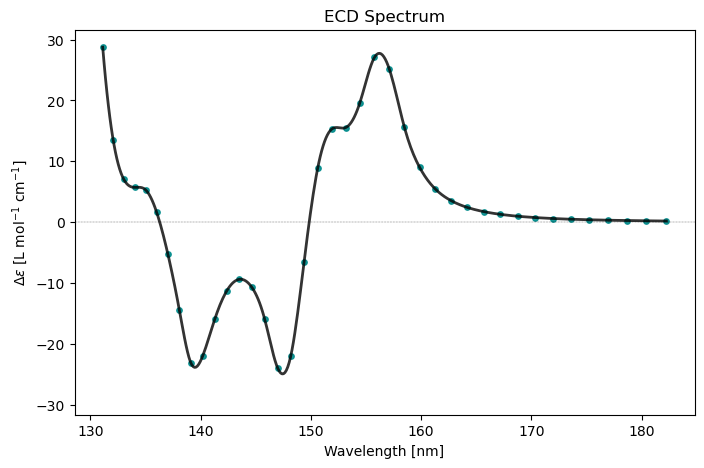

In [20]:
cpp_drv.plot(cpp_results)

**Text file**

:::{code}
@jobs
task: response
@end

@method settings
basis: def2-svpd
xcfun: b3lyp
@end

@response
property: ecd (cpp)
! frequency region (and resolution)
frequencies: 0.05-0.15 (0.0025)
damping: 0.0045563  ! this is the default value
@end

@molecule
charge: 0
multiplicity: 1
xyz:
...
@end
:::

(sec:ecm)=
## Exciton coupling model

VeloxChem implements the exciton coupling model to determine circular dichroism spectra.

In [ ]:
import math
from typing import List, Tuple

Atom = Tuple[str, float, float, float]


def build_ethylene_local(r_CC: float = 1.339, r_CH: float = 1.087) -> List[Atom]:
    """
    Construct a planar ethylene (C2H4) centered at the origin in the xy-plane.
    - C atoms placed at (-r_CC/2, 0, 0) and (+r_CC/2, 0, 0)
    - For each carbon, two hydrogens arranged trigonal-planar (120° apart),
      with the C-C bond being one of the three sp2 directions.

    Returns:
        List of (element, x, y, z) for 6 atoms: C, C, H, H, H, H
    """
    d = r_CC
    # Carbon positions
    c1 = (-d / 2.0, 0.0, 0.0)
    c2 = (d / 2.0, 0.0, 0.0)

    # Around C1: one bond to C2 at angle 0°; hydrogens at ±120° from +x
    ang1a = math.radians(120.0)
    ang1b = math.radians(-120.0)
    h1 = (c1[0] + r_CH * math.cos(ang1a), c1[1] + r_CH * math.sin(ang1a), 0.0)
    h2 = (c1[0] + r_CH * math.cos(ang1b), c1[1] + r_CH * math.sin(ang1b), 0.0)

    # Around C2: one bond to C1 at 180°; hydrogens at 180° ± 120° -> 60° and -60°
    ang2a = math.radians(60.0)
    ang2b = math.radians(-60.0)
    h3 = (c2[0] + r_CH * math.cos(ang2a), c2[1] + r_CH * math.sin(ang2a), 0.0)
    h4 = (c2[0] + r_CH * math.cos(ang2b), c2[1] + r_CH * math.sin(ang2b), 0.0)

    atoms = [
        ("C", *c1),
        ("C", *c2),
        ("H", *h1),
        ("H", *h2),
        ("H", *h3),
        ("H", *h4),
    ]
    return atoms


def rotate_z(x: float, y: float, z: float, phi: float) -> Tuple[float, float, float]:
    """
    Rotate a point around the z-axis by angle phi (radians).
    """
    c = math.cos(phi)
    s = math.sin(phi)
    xr = c * x - s * y
    yr = s * x + c * y
    return xr, yr, z


def build_stack(
    n_units: int,
    twist_deg: float,
    rise: float,
    radius: float,
    r_CC: float,
    r_CH: float,
) -> List[Atom]:
    """
    Build the full helical stack of ethylenes.

    Args:
        n_units: number of ethylene units
        twist_deg: twist angle per step (degrees)
        rise: translation along z per step (Å)
        radius: helix radius for the molecule centroids (Å)
        r_CC: C=C bond length (Å)
        r_CH: C–H bond length (Å)

    Returns:
        List of atoms for the whole stack.
    """
    base = build_ethylene_local(r_CC=r_CC, r_CH=r_CH)
    all_atoms: List[Atom] = []
    for k in range(n_units):
        phi = math.radians(k * twist_deg)
        # Helix center for unit k
        cx = radius * math.cos(phi)
        cy = radius * math.sin(phi)
        cz = k * rise

        for el, x, y, z in base:
            xr, yr, zr = rotate_z(x, y, z, phi)
            all_atoms.append((el, xr + cx, yr + cy, zr + cz))

    return all_atoms


atoms = build_stack(
    n_units=10,
    twist_deg=10,
    rise=3.5,
    radius=0,
    r_CC=1.339,
    r_CH=1.087,
)

mol_str = ""
for el, x, y, z in atoms:
    mol_str += f"{el:2s} {x:12.6f} {y:12.6f} {z:12.6f}\n"

In [23]:
molecule = vlx.Molecule.read_str(mol_str)

In [24]:
molecule.show()

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

**Python script**

In [25]:
import veloxchem as vlx

molecule = vlx.Molecule.read_str(mol_str)
basis = vlx.MolecularBasis.read(molecule, "def2-svp")

exciton_drv = vlx.ExcitonModelDriver()

exciton_drv.xcfun_label = "b3lyp"
exciton_drv.nstates = 2
exciton_drv.ct_nocc = 0
exciton_drv.ct_nvir = 0

**Text file**

:::{code}
@jobs
task: exciton
@end

@method settings
xcfun: b3lyp
basis: cc-pvdz
@end

@exciton
fragments: 40
atoms_per_fragment: 55
nstates: 5
ct_nocc: 0
ct_nvir: 0
@end

@molecule
charge: 0
multiplicity: 1
xyz:
...
! XYZ coordinates for 40 x 55 atoms
...
@end
:::